# Benchmark H2O Klasik — Rigid Scan (SP), R = 0.20–3.00 Å
### Perbandingan Kurva Energi Potensial (PES) O-H pada H₂O
**Metode:** HF, B3LYP (DFT), CASSCF(8,6), CASCI approx. (maxiter=1), FCI(10,7) — basis set STO-3G

---
**Catatan metodologi:**
- Scan menggunakan metode **Rigid Scan (Single Point/SP)**: jarak O-H di-scan dari 0.20–3.00 Å (16 titik uniform), koordinat atom lainnya difiksasi.
- Geometri menggunakan hasil optimasi Avogadro yang ditranslasikan ke origin:
  `O(0,0,0), H(0,0,R), H(-0.8604, 0.2094, 0.3936)`
- **CASCI approx.** menggunakan `maxiter=1` (bukan CASCI murni karena `maxiter=0` menyebabkan I/O error di ORCA 6.0.1).
- **FCI(10,7)** = CASSCF(nel=10, norb=7)/STO-3G → referensi eksak dalam basis STO-3G.
- FCI digunakan sebagai referensi eksak untuk perhitungan error pada seluruh metode lainnya.


In [2]:
import matplotlib.pyplot as plt
import numpy as np

## 1. Data Hasil Simulasi (ORCA, Rigid Scan / SP)


In [3]:
import numpy as np

# ── Jarak ikatan O-H (Å) — 16 titik uniform, R = 0.20–3.00 Å ──
R = list(np.linspace(0.20, 3.00, 16))

# ── HF/STO-3G (Rigid Scan) ──
E_HF = [-65.735275501498, -72.702155643210, -74.337376631838, -74.786126526308,
        -74.896650936002, -74.895420608677, -74.854576412963, -74.801353387364,
        -74.746422105835, -74.695015235522, -74.649968489797, -74.612242153674,
        -74.581554088567, -74.557067199219, -74.537789704551, -74.522741366701]

# ── B3LYP/STO-3G (Rigid Scan) ──
E_DFT = [-66.043081275817, -73.010605153956, -74.645967862402, -75.098408057665,
         -75.218156277167, -75.230366815495, -75.205165113982, -75.168221178915,
         -75.129218266938, -75.092744504141, -75.061229280520, -75.035421784978,
         -75.014999824923, -74.999213611590, -74.987248525569, -74.978349015496]

# ── CASSCF(8,6)/STO-3G (Rigid Scan) ──
E_CASSCF = [-65.757320098911, -72.734580452894, -74.377404524723, -74.833806109847,
            -74.954554727109, -74.967530015552, -74.945878256011, -74.917401070167,
            -74.892623342207, -74.875118637178, -74.864594967332, -74.858944646042,
            -74.856105443588, -74.854733680851, -74.854091639597, -74.853800879516]

# ── CASCI approx. (maxiter=1)/STO-3G (Rigid Scan) ──
E_CASCI = [-65.757067266300, -69.763432162567, -71.969541184849, -73.050181166408,
           -73.670618453598, -74.011412714248, -74.190627064914, -74.281543028687,
           -74.324358891706, -74.340879451330, -74.343128102772, -74.337820499044,
           -74.328740667060, -74.318043644529, -74.306954817147, -74.296148421311]

# ── FCI(10,7)/STO-3G (Referensi Eksak, Rigid Scan) ──
E_FCI = [-65.757353694391, -72.734614585688, -74.377456586121, -74.833847216012,
         -74.954584930755, -74.967554063772, -74.945898763863, -74.917419238376,
         -74.892639741124, -74.875133632490, -74.864608919457, -74.858957916566,
         -74.856118324517, -74.854746341513, -74.854104186321, -74.853813368661]

print(f'Jumlah titik R : {len(R)}')
print(f'Range R        : {R[0]:.2f} – {R[-1]:.2f} Å')
print(f'Step R         : {R[1]-R[0]:.4f} Å')


Jumlah titik R : 16
Range R        : 0.20 – 3.00 Å
Step R         : 0.1867 Å


## 2. Hitung Error Relatif

Referensi: **FCI(10,7)** — energi eksak dalam basis set STO-3G.


In [4]:
# ── Referensi: FCI ──
e_ref        = np.array(E_FCI)
error_hf     = np.abs(np.array(E_HF)     - e_ref)
error_dft    = np.abs(np.array(E_DFT)    - e_ref)
error_casscf = np.abs(np.array(E_CASSCF) - e_ref)
error_casci  = np.abs(np.array(E_CASCI)  - e_ref)

CA = 0.0016  # Chemical Accuracy (Hartree)

idx_fci = E_FCI.index(min(E_FCI))

print(f'R_eq (FCI) = {R[idx_fci]:.2f} Å | E = {E_FCI[idx_fci]:.6f} Ha')
print(f'Mean |ΔE| HF     vs FCI = {np.mean(error_hf):.6e} Ha')
print(f'Mean |ΔE| B3LYP  vs FCI = {np.mean(error_dft):.6e} Ha')
print(f'Mean |ΔE| CASSCF vs FCI = {np.mean(error_casscf):.6e} Ha')
print(f'Mean |ΔE| CASCI  vs FCI = {np.mean(error_casci):.6e} Ha')


R_eq (FCI) = 1.13 Å | E = -74.967554 Ha
Mean |ΔE| HF     vs FCI = 1.554447e-01 Ha
Mean |ΔE| B3LYP  vs FCI = 2.199716e-01 Ha
Mean |ΔE| CASSCF vs FCI = 2.268863e-05 Ha
Mean |ΔE| CASCI  vs FCI = 9.442721e-01 Ha


## 3. Plot Kurva Energi Potensial (PES) dan Error

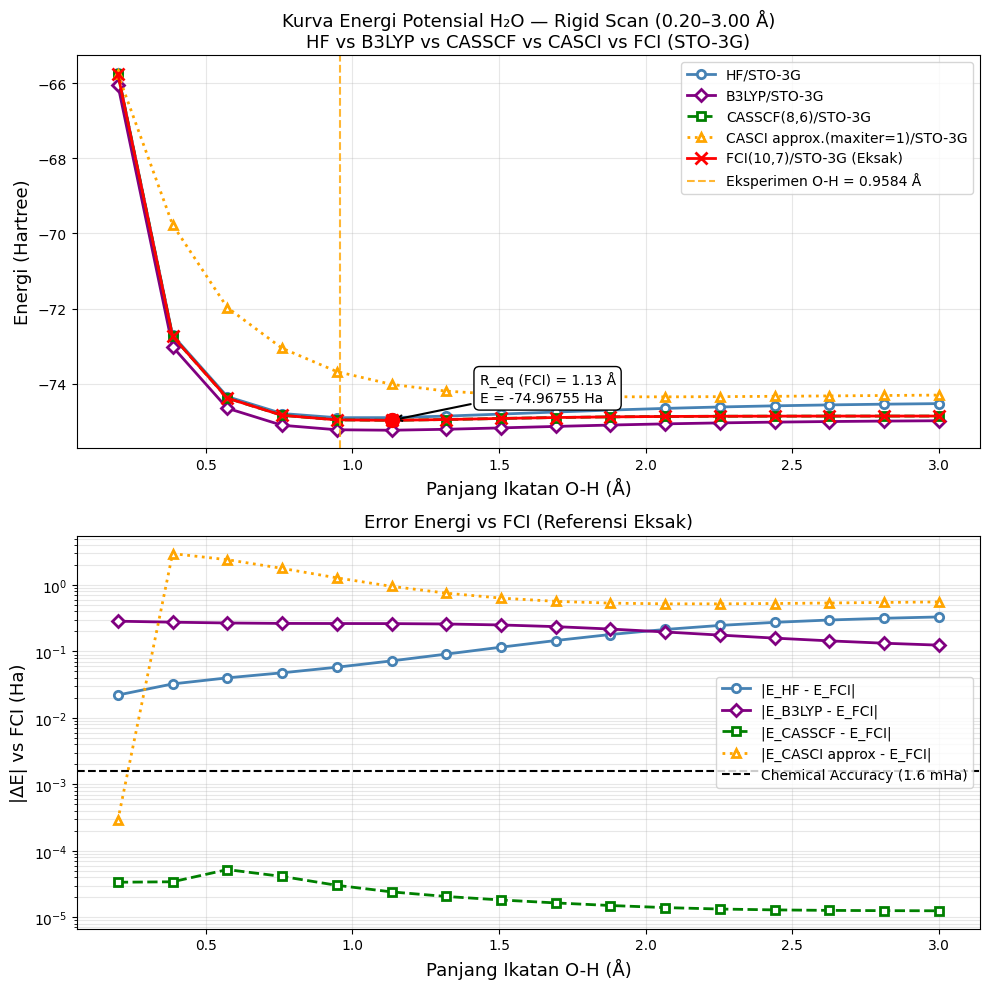

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# ── Plot 1: PES ──
ax1.plot(R, E_HF,     'o-',  color='steelblue', linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='HF/STO-3G')
ax1.plot(R, E_DFT,    'D-',  color='purple',    linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='B3LYP/STO-3G')
ax1.plot(R, E_CASSCF, 's--', color='green',     linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='CASSCF(8,6)/STO-3G')
ax1.plot(R, E_CASCI,  '^:',  color='orange',    linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='CASCI approx.(maxiter=1)/STO-3G')
ax1.plot(R, E_FCI,    'x-',  color='red',       linewidth=2,
         markersize=8, markeredgewidth=2,
         label='FCI(10,7)/STO-3G (Eksak)')

ax1.plot(R[idx_fci], E_FCI[idx_fci], 'ro', markersize=10, zorder=5)
ax1.annotate(f'R_eq (FCI) = {R[idx_fci]:.2f} Å\nE = {E_FCI[idx_fci]:.5f} Ha',
             xy=(R[idx_fci], E_FCI[idx_fci]),
             xytext=(R[idx_fci]+0.3, E_FCI[idx_fci]+0.5),
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
             fontsize=10,
             bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                       edgecolor='black', linewidth=1))

ax1.axvline(x=0.9584, color='orange', linestyle='--',
            linewidth=1.5, alpha=0.8, label='Eksperimen O-H = 0.9584 Å')
ax1.set_xlabel('Panjang Ikatan O-H (Å)', fontsize=13)
ax1.set_ylabel('Energi (Hartree)', fontsize=13)
ax1.set_title('Kurva Energi Potensial H₂O — Rigid Scan (0.20–3.00 Å)\n'
              'HF vs B3LYP vs CASSCF vs CASCI vs FCI (STO-3G)',
              fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# ── Plot 2: Error vs FCI ──
ax2.semilogy(R, error_hf     + 1e-10, 'o-',  color='steelblue', linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_HF - E_FCI|')
ax2.semilogy(R, error_dft    + 1e-10, 'D-',  color='purple',    linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_B3LYP - E_FCI|')
ax2.semilogy(R, error_casscf + 1e-10, 's--', color='green',     linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_CASSCF - E_FCI|')
ax2.semilogy(R, error_casci  + 1e-10, '^:',  color='orange',    linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_CASCI approx - E_FCI|')
ax2.axhline(y=CA, color='black', linestyle='--',
            linewidth=1.5, label='Chemical Accuracy (1.6 mHa)')
ax2.set_xlabel('Panjang Ikatan O-H (Å)', fontsize=13)
ax2.set_ylabel('|ΔE| vs FCI (Ha)', fontsize=13)
ax2.set_title('Error Energi vs FCI (Referensi Eksak)', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('PES_H2O_SP_0.2to3.0.png', dpi=150, bbox_inches='tight')
plt.show()


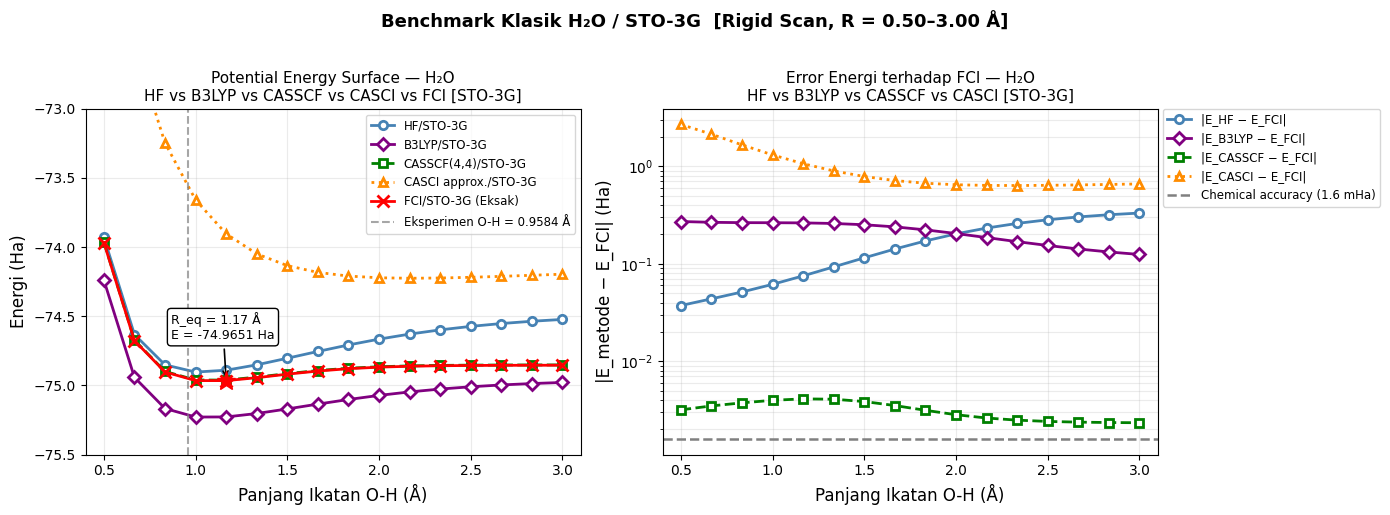

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# ── Data H2O Range 0.50–3.00 Å, 16 titik ──
R = list(np.linspace(0.50, 3.00, 16))

E_HF = [-73.930018016201, -74.631993570884, -74.851310231601, -74.903198176766,
        -74.889893926765, -74.851003445440, -74.803324202888, -74.754146031385,
        -74.707346094596, -74.665231989152, -74.628846017067, -74.598270373412,
        -74.573053758190, -74.552531825060, -74.535991837479, -74.522741328202]

E_DFT = [-74.238470313661, -74.941732664821, -75.166593759953, -75.228202091072,
         -75.227525917828, -75.202748255836, -75.169612159117, -75.134715691938,
         -75.101461466627, -75.071836955031, -75.046699389983, -75.026048580948,
         -75.009460340773, -74.996354544024, -74.986161269388, -74.978349020645]

E_CASSCF = [-73.964142412695, -74.672197957544, -74.898898030237, -74.960748084964,
            -74.960947077781, -74.939819740199, -74.914542708059, -74.892249577470,
            -74.875652380195, -74.864852317765, -74.858500725969, -74.855000065089,
            -74.853144097917, -74.852186363343, -74.851704693283, -74.851469078941]

E_CASCI = [-71.285860470888, -72.545477684934, -73.247846017575, -73.658963014780,
           -73.903856814660, -74.048952590918, -74.134049526055, -74.182923416708,
           -74.209400124280, -74.221780633675, -74.225313181297, -74.223408760256,
           -74.218297818651, -74.211432238080, -74.203743978541, -74.195816026233]

E_FCI = [-73.967320311231, -74.675685711829, -74.902647677734, -74.964730740326,
         -74.965065779436, -74.943905156826, -74.918408931490, -74.895767720297,
         -74.878795549211, -74.867685629108, -74.861121712364, -74.857491995498,
         -74.855562422342, -74.854564229068, -74.854060700756, -74.853813368661]

# ── Error vs FCI ──
e_ref        = np.array(E_FCI)
error_hf     = np.abs(np.array(E_HF)     - e_ref)
error_dft    = np.abs(np.array(E_DFT)    - e_ref)
error_casscf = np.abs(np.array(E_CASSCF) - e_ref)
error_casci  = np.abs(np.array(E_CASCI)  - e_ref)
CA = 0.0016

idx_fci = E_FCI.index(min(E_FCI))

# ── Plot Side-by-Side seperti grafik contoh ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

# ── Skala x: sama di kedua panel ──
xlim = (0.4, 3.1)

# ─────────────────────────────────────
# Panel Kiri: PES
# ─────────────────────────────────────
ax1.set_ylim(-75.5, -73.0)
ax1.plot(R, E_HF,     'o-',  color='steelblue', linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='HF/STO-3G')
ax1.plot(R, E_DFT,    'D-',  color='purple',    linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='B3LYP/STO-3G')
ax1.plot(R, E_CASSCF, 's--', color='green',     linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='CASSCF(4,4)/STO-3G')
ax1.plot(R, E_CASCI,  '^:',  color='darkorange', linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='CASCI approx./STO-3G')
ax1.plot(R, E_FCI,    'x-',  color='red',        linewidth=2,
         markersize=8, markeredgewidth=2,
         label='FCI/STO-3G (Eksak)')

# Titik minimum FCI
ax1.plot(R[idx_fci], E_FCI[idx_fci], 'r*', markersize=14, zorder=5)
ax1.annotate(f'R_eq = {R[idx_fci]:.2f} Å\nE = {E_FCI[idx_fci]:.4f} Ha',
             xy=(R[idx_fci], E_FCI[idx_fci]),
             xytext=(R[idx_fci]-0.3, E_FCI[idx_fci]+0.3),
             arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
             fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black'))

ax1.axvline(x=0.9584, color='gray', linestyle='--', linewidth=1.5, alpha=0.7,
            label='Eksperimen O-H = 0.9584 Å')
ax1.set_xlim(xlim)
ax1.set_xlabel('Panjang Ikatan O-H (Å)', fontsize=12)
ax1.set_ylabel('Energi (Ha)', fontsize=12)
ax1.set_title('Potential Energy Surface — H₂O\nHF vs B3LYP vs CASSCF vs CASCI vs FCI [STO-3G]',
              fontsize=11)

ax1.grid(True, alpha=0.25)

# ─────────────────────────────────────
# Panel Kanan: Error vs FCI (Ha, log)
# ─────────────────────────────────────
ax2.semilogy(R, error_hf     + 1e-10, 'o-',  color='steelblue',  linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_HF − E_FCI|')
ax2.semilogy(R, error_dft    + 1e-10, 'D-',  color='purple',     linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_B3LYP − E_FCI|')
ax2.semilogy(R, error_casscf + 1e-10, 's--', color='green',      linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_CASSCF − E_FCI|')
ax2.semilogy(R, error_casci  + 1e-10, '^:',  color='darkorange', linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_CASCI − E_FCI|')
ax2.axhline(y=CA, color='gray', linestyle='--', linewidth=1.8,
            label='Chemical accuracy (1.6 mHa)')

ax2.set_xlim(xlim)
ax2.set_xlabel('Panjang Ikatan O-H (Å)', fontsize=12)
ax2.set_ylabel('|E_metode − E_FCI| (Ha)', fontsize=12)
ax2.set_title('Error Energi terhadap FCI — H₂O\nHF vs B3LYP vs CASSCF vs CASCI [STO-3G]',
              fontsize=11)

ax2.grid(True, alpha=0.25, which='both')
# Panel kiri
ax1.legend(fontsize=8.5, loc='upper right', 
           bbox_to_anchor=(1.0, 1.0))

# Panel kanan - taruh di luar kanan
ax2.legend(fontsize=8.5, 
           bbox_to_anchor=(1.01, 1.0), 
           loc='upper left',
           borderaxespad=0)


plt.subplots_adjust(bottom=0.25)  # kasih ruang untuk legend bawah
plt.suptitle('Benchmark Klasik H₂O / STO-3G  [Rigid Scan, R = 0.50–3.00 Å]',
             fontsize=13, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

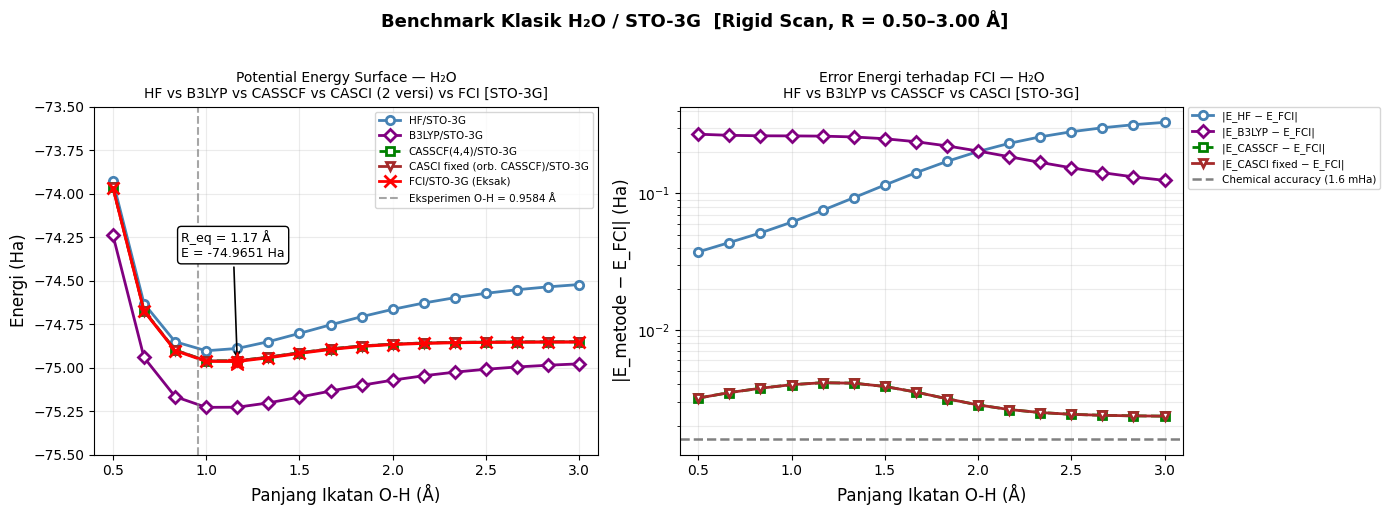

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# ── Data H2O Range 0.50–3.00 Å, 16 titik ──
R = list(np.linspace(0.50, 3.00, 16))

E_HF = [-73.930018016201, -74.631993570884, -74.851310231601, -74.903198176766,
        -74.889893926765, -74.851003445440, -74.803324202888, -74.754146031385,
        -74.707346094596, -74.665231989152, -74.628846017067, -74.598270373412,
        -74.573053758190, -74.552531825060, -74.535991837479, -74.522741328202]

E_DFT = [-74.238470313661, -74.941732664821, -75.166593759953, -75.228202091072,
         -75.227525917828, -75.202748255836, -75.169612159117, -75.134715691938,
         -75.101461466627, -75.071836955031, -75.046699389983, -75.026048580948,
         -75.009460340773, -74.996354544024, -74.986161269388, -74.978349020645]

E_CASSCF = [-73.964142412695, -74.672197957544, -74.898898030237, -74.960748084964,
            -74.960947077781, -74.939819740199, -74.914542708059, -74.892249577470,
            -74.875652380195, -74.864852317765, -74.858500725969, -74.855000065089,
            -74.853144097917, -74.852186363343, -74.851704693283, -74.851469078941]

# CASCI approx: orbital HF (versi lama, error besar)
#E_CASCI = [-71.285860470888, -72.545477684934, -73.247846017575, -73.658963014780,
#           -73.903856814660, -74.048952590918, -74.134049526055, -74.182923416708,
#           -74.209400124280, -74.221780633675, -74.225313181297, -74.223408760256,
#           -74.218297818651, -74.211432238080, -74.203743978541, -74.195816026233]

# CASCI fixed: orbital CASSCF (versi baru, dari H2O_CASCI_fixed.*.out)
# Identik dengan CASSCF karena orbital referensinya sudah optimal
E_CASCI_fixed = [-73.964142412695, -74.672197957544, -74.898898030237, -74.960748084964,
                 -74.960947077781, -74.939819740199, -74.914542708059, -74.892249577470,
                 -74.875652380195, -74.864852317765, -74.858500725969, -74.855000065089,
                 -74.853144097917, -74.852186363343, -74.851704693283, -74.851469078941]

E_FCI = [-73.967320311231, -74.675685711829, -74.902647677734, -74.964730740326,
         -74.965065779436, -74.943905156826, -74.918408931490, -74.895767720297,
         -74.878795549211, -74.867685629108, -74.861121712364, -74.857491995498,
         -74.855562422342, -74.854564229068, -74.854060700756, -74.853813368661]

# ── Error vs FCI ──
e_ref             = np.array(E_FCI)
error_hf          = np.abs(np.array(E_HF)          - e_ref)
error_dft         = np.abs(np.array(E_DFT)          - e_ref)
error_casscf      = np.abs(np.array(E_CASSCF)       - e_ref)
error_casci       = np.abs(np.array(E_CASCI)        - e_ref)
error_casci_fixed = np.abs(np.array(E_CASCI_fixed)  - e_ref)
CA = 0.0016

idx_fci = E_FCI.index(min(E_FCI))

# ── Plot ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')
xlim = (0.4, 3.1)

# ─────────────────────────────────────
# Panel Kiri: PES
# ─────────────────────────────────────
ax1.set_ylim(-75.5, -73.5)  # diperlebar ke bawah karena CASCI approx turun jauh

ax1.plot(R, E_HF,          'o-',  color='steelblue',   linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='HF/STO-3G')
ax1.plot(R, E_DFT,         'D-',  color='purple',      linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='B3LYP/STO-3G')
ax1.plot(R, E_CASSCF,      's--', color='green',       linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='CASSCF(4,4)/STO-3G')
#ax1.plot(R, E_CASCI,       '^:',  color='darkorange',  linewidth=2,
#         markersize=6, markerfacecolor='white', markeredgewidth=2,
#         label='CASCI approx. (orb. HF)/STO-3G')
ax1.plot(R, E_CASCI_fixed, 'v-',  color='brown',       linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='CASCI fixed (orb. CASSCF)/STO-3G')
ax1.plot(R, E_FCI,         'x-',  color='red',         linewidth=2,
         markersize=8, markeredgewidth=2,
         label='FCI/STO-3G (Eksak)')

# Titik minimum FCI
ax1.plot(R[idx_fci], E_FCI[idx_fci], 'r*', markersize=14, zorder=5)
ax1.annotate(f'R_eq = {R[idx_fci]:.2f} Å\nE = {E_FCI[idx_fci]:.4f} Ha',
             xy=(R[idx_fci], E_FCI[idx_fci]),
             xytext=(R[idx_fci]-0.3, E_FCI[idx_fci]+0.6),
             arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
             fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black'))

ax1.axvline(x=0.9584, color='gray', linestyle='--', linewidth=1.5, alpha=0.7,
            label='Eksperimen O-H = 0.9584 Å')

ax1.set_xlim(xlim)
ax1.set_xlabel('Panjang Ikatan O-H (Å)', fontsize=12)
ax1.set_ylabel('Energi (Ha)', fontsize=12)
ax1.set_title('Potential Energy Surface — H₂O\nHF vs B3LYP vs CASSCF vs CASCI (2 versi) vs FCI [STO-3G]',
              fontsize=10)
ax1.grid(True, alpha=0.25)
ax1.legend(fontsize=7.5, loc='upper right')

# ─────────────────────────────────────
# Panel Kanan: Error vs FCI (log scale)
# ─────────────────────────────────────
ax2.semilogy(R, error_hf          + 1e-10, 'o-',  color='steelblue',  linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_HF − E_FCI|')
ax2.semilogy(R, error_dft         + 1e-10, 'D-',  color='purple',     linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_B3LYP − E_FCI|')
ax2.semilogy(R, error_casscf      + 1e-10, 's--', color='green',      linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_CASSCF − E_FCI|')
#ax2.semilogy(R, error_casci       + 1e-10, '^:',  color='darkorange', linewidth=2,
#             markersize=6, markerfacecolor='white', markeredgewidth=2,
#             label='|E_CASCI approx. − E_FCI|')
ax2.semilogy(R, error_casci_fixed + 1e-10, 'v-',  color='brown',      linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_CASCI fixed − E_FCI|')
ax2.axhline(y=CA, color='gray', linestyle='--', linewidth=1.8,
            label='Chemical accuracy (1.6 mHa)')

ax2.set_xlim(xlim)
ax2.set_xlabel('Panjang Ikatan O-H (Å)', fontsize=12)
ax2.set_ylabel('|E_metode − E_FCI| (Ha)', fontsize=12)
ax2.set_title('Error Energi terhadap FCI — H₂O\nHF vs B3LYP vs CASSCF vs CASCI [STO-3G]',
              fontsize=10)
ax2.grid(True, alpha=0.25, which='both')
ax2.legend(fontsize=7.5,
           bbox_to_anchor=(1.01, 1.0),
           loc='upper left',
           borderaxespad=0)

plt.suptitle('Benchmark Klasik H₂O / STO-3G  [Rigid Scan, R = 0.50–3.00 Å]',
             fontsize=13, weight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Benchmark_H2O_5Metode.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# ── Ringkasan Energi Elektronik ──
print('='*65)
print('RINGKASAN ENERGI ELEKTRONIK H₂O (STO-3G), R = 0.20–3.00 Å')
print('='*65)
print(f'{"Metode":<22} {"E_min (Ha)":>15} {"R_eq (Å)":>10} {"ΔE vs FCI":>12}')
print('-'*65)
datasets = {
    'HF':            E_HF,
    'B3LYP':         E_DFT,
    'CASSCF(8,6)':   E_CASSCF,
    'CASCI approx.': E_CASCI,
    'FCI(10,7)':     E_FCI,
}
e_fci_min = min(E_FCI)
for nama, E in datasets.items():
    idx   = E.index(min(E))
    delta = abs(E[idx] - e_fci_min)
    print(f'{nama:<22} {E[idx]:>15.6f} {R[idx]:>10.2f} {delta:>12.6e}')
print('='*65)


RINGKASAN ENERGI ELEKTRONIK H₂O (STO-3G), R = 0.20–3.00 Å
Metode                      E_min (Ha)   R_eq (Å)    ΔE vs FCI
-----------------------------------------------------------------
HF                          -74.903198       1.00 6.186760e-02
B3LYP                       -75.228202       1.00 2.631363e-01
CASSCF(8,6)                 -74.960947       1.17 4.118702e-03
CASCI approx.               -74.225313       2.17 7.397526e-01
FCI(10,7)                   -74.965066       1.17 0.000000e+00
